### **Pixel-to-Metre Sequence Processor**

#### **1. Imports and Setup**

In [1]:
import os
import cv2
import numpy as np
import torch
import PIL.Image
from ultralytics import YOLO
from IPython.display import Video, display

# Ensure output directory exists
os.makedirs("output", exist_ok=True)

#### **2. Configuration**

Define your constants here. We will process 60 frames starting from a specific index.

In [2]:
# Configuration
YOLO_MARKER_MODEL_PATH = "runs/detect/runs/detect/marker_detector/weights/best.pt"
YOLO_PERSON_MODEL_PATH = "yolov8s.pt" # Standard person detection
FRAMES_DIR = "frames/under/Bottom_Freestyle_P034_1/"
START_FRAME_IDX = 0
NUM_FRAMES = -1  # Set to -1 to process all frames
FPS = 60  # Frames per second for the output video

MARKER_REAL_DIST_M = 2.5
YOLO_CONF = 0.3 # down from à.è
OUTPUT_VIDEO_PATH = "output/swimmer_tracking_demo_full_freestyle_p034_1.mp4"

# Load Models
marker_model = YOLO(YOLO_MARKER_MODEL_PATH)
person_model = YOLO(YOLO_PERSON_MODEL_PATH)

# Transformers for ViTPose
from transformers import AutoProcessor, VitPoseForPoseEstimation
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

try:
    pose_model_name = "usyd-community/vitpose-plus-large"
    pose_image_processor = AutoProcessor.from_pretrained(pose_model_name)
    pose_model = VitPoseForPoseEstimation.from_pretrained(pose_model_name, device_map=device)
    print("Transformers ViTPose Model Loaded!")
except Exception as e:
    print(f"Error loading ViTPose: {e}")

Using device: cuda


The image processor of type `VitPoseImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/691 [00:00<?, ?it/s]

Transformers ViTPose Model Loaded!


#### **3. Processing Loop**

This script iterates through the frames, performs detection, calculates distances, draws the visualization, and writes to a video file.

In [4]:
def get_centroid(box):
    x1, y1, x2, y2 = box
    return np.array([(x1 + x2) / 2, (y1 + y2) / 2])

def put_text_bg(img, text, pos, color, scale=0.7, alpha=0.5):
    """Draws text with a semi-transparent black background, matching matplotlib."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    thickness = 2
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    x, y = pos
    x1, y1 = int(max(0, x-5)), int(max(0, y-th-5))
    x2, y2 = int(min(img.shape[1], x+tw+5)), int(min(img.shape[0], y+baseline+5))
    
    if x2 > x1 and y2 > y1:
        overlay = img[y1:y2, x1:x2].copy()
        cv2.rectangle(overlay, (0, 0), (x2-x1, y2-y1), (0, 0, 0), -1)
        cv2.addWeighted(overlay, alpha, img[y1:y2, x1:x2], 1 - alpha, 0, img[y1:y2, x1:x2])
        
    cv2.putText(img, text, (x, y), font, scale, color, thickness, cv2.LINE_AA)

# Initialize Video Writer
# Note: 'mp4v' is widely supported; 'avc1' is better for browser playback if available
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_writer = None
warp_out_writer = None
WARP_OUTPUT_VIDEO_PATH = OUTPUT_VIDEO_PATH.replace('.mp4', '_warped.mp4')
target_h, target_w = 0, 0

MARKER_HEIGHT_M = 0.6  # From demo

tracking_records = []

frame_range = range(NUM_FRAMES) if NUM_FRAMES > 0 else range(START_FRAME_IDX, START_FRAME_IDX + len(os.listdir(FRAMES_DIR)))
frame_paths = [os.path.join(FRAMES_DIR, f"{START_FRAME_IDX + i:05d}.jpg") for i in frame_range]

# Optimisation (4): Process Inference in Batches
BATCH_SIZE = 16  
print(f"Processing {len(frame_paths)} frames using batch size of {BATCH_SIZE}...")

# Optimisation (2): Stabilization Variables for Perspective Transform
smoothed_src_pts = None
prev_marker_pair = None
EMA_ALPHA = 0.15 # 15% new coordinates, 85% previous coordinates. Smoothes perspective jitter.
_prev_warp_state = None

# Track known physical markers persistently to prevent ID swapping jumps
tracked_markers = {}
MAX_TRACK_DIST_PX = 150.0  # Maximum pixels a marker can move frame-to-frame

for b in range(0, len(frame_paths), BATCH_SIZE):
    batch_paths = frame_paths[b:b+BATCH_SIZE]
    batch_frames = []
    
    # Load batch
    for p in batch_paths:
        f = cv2.imread(p)
        if f is not None:
            batch_frames.append(f)
        else:
            print(f"Warning: Could not load {p}")
            
    if not batch_frames:
        continue

    img_h, img_w = batch_frames[0].shape[:2]

    # Run batched YOLO detection (utilises GPU more efficiently)
    marker_results = marker_model.predict(batch_frames, conf=YOLO_CONF, verbose=False)
    # Using a much lower confidence for the standard person model so it catches the swimmer
    person_results = person_model.predict(batch_frames, conf=0.15, verbose=False)

    for idx_in_batch, (frame, m_res, p_res) in enumerate(zip(batch_frames, marker_results, person_results)):
        frame_idx = START_FRAME_IDX + b + idx_in_batch
        
        swimmer_centroid = None
        swimmer_hbox     = None
        swimmer_kpts     = None
        swimmer_kpt_scores = None
        _box_records     = []
        
        current_marker_detections = []

        # 1. Process markers
        for box in m_res.boxes:
            cls            = int(box.cls)
            conf           = float(box.conf)
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cx, cy         = (x1 + x2) / 2, (y1 + y2) / 2
            if cls == 0:
                _box_records.append((cls, conf, x1, y1, x2, y2, cx, cy))
                current_marker_detections.append({"pt": (cx, cy), "box": (x1, y1, x2, y2, cx, cy)})

        # 2. Process person + ViTPose (Hips Centroid)
        best_person_conf = -1.0
        person_box = None
        for box in p_res.boxes:
            cls = int(box.cls)
            conf = float(box.conf)
            if cls == 0 and conf > best_person_conf: # COCO person class
                person_box = box.xyxy[0].tolist()
                best_person_conf = conf

        if person_box is not None:
            x1, y1, x2, y2 = [int(v) for v in person_box]
            swimmer_hbox = (x1, y1, x2, y2)
            
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            vitpose_boxes = np.array([[x1, y1, bbox_w, bbox_h]])
            
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img = PIL.Image.fromarray(img_rgb)
            inputs = pose_image_processor(pil_img, boxes=[vitpose_boxes], return_tensors="pt").to(device)
            
            if pose_model.config.backbone_config.num_experts > 1:
                inputs["dataset_index"] = torch.tensor([0] * len(inputs["pixel_values"])).to(device)

            with torch.no_grad():
                outputs = pose_model(**inputs)
            
            pose_results = pose_image_processor.post_process_pose_estimation(outputs, boxes=[vitpose_boxes])
            
            if len(pose_results) > 0 and len(pose_results[0]) > 0:
                person_pose = pose_results[0][0]
                kpts = person_pose["keypoints"].cpu().numpy()
                scores = person_pose["scores"].cpu().numpy()
                
                swimmer_kpts = kpts
                swimmer_kpt_scores = scores
                
                # Check for hips (11 and 12)
                if len(kpts) > 12 and scores[11] > 0.1 and scores[12] > 0.1:
                    lh = kpts[11]
                    rh = kpts[12]
                    swimmer_centroid = (int((lh[0] + rh[0]) / 2), int((lh[1] + rh[1]) / 2))

        # -----------------------------
        # MARKER TRACKING LOGIC
        # -----------------------------
        new_tracked_markers = {}
        if not tracked_markers and current_marker_detections:
            # First frame initialization: assign physical IDs 1, 2, 3 left-to-right
            current_marker_detections = sorted(current_marker_detections, key=lambda m: m["pt"][0])
            for i, md in enumerate(current_marker_detections, start=1):
                new_tracked_markers[i] = md
        elif current_marker_detections:
            unassigned = current_marker_detections.copy()
            # 1. Match existing tracked markers
            for t_id, t_data in tracked_markers.items():
                if not unassigned: break
                t_pt = t_data["pt"]
                dists = [np.linalg.norm(np.array(t_pt) - np.array(u["pt"])) for u in unassigned]
                min_i = np.argmin(dists)
                if dists[min_i] < MAX_TRACK_DIST_PX:
                    new_tracked_markers[t_id] = unassigned[min_i]
                    unassigned.pop(min_i)
            
            # 2. Assign IDs to new markers entering frame
            for u in unassigned:
                if not new_tracked_markers:
                    # Failsafe if we somehow lost everything
                    new_tracked_markers[1] = u
                    continue
                
                # Sort the currently tracked ones left-to-right to deduce position
                sorted_known = sorted(new_tracked_markers.items(), key=lambda item: item[1]["pt"][0])
                leftmost_id, leftmost_data = sorted_known[0]
                rightmost_id, rightmost_data = sorted_known[-1]
                
                # Assign ID relative to the leftmost or rightmost physical tracker
                if u["pt"][0] < leftmost_data["pt"][0]:
                    new_id = leftmost_id - 1
                else:
                    new_id = rightmost_id + 1
                
                # Failsafe against collisions
                while new_id in new_tracked_markers:
                    new_id += 1 if u["pt"][0] > rightmost_data["pt"][0] else -1
                    
                new_tracked_markers[new_id] = u
                
        tracked_markers = new_tracked_markers
        
        out_frame = frame.copy()

        # Draw Swimmer Box and ViTPose Keypoints like in prototyping
        if swimmer_hbox is not None:
            sx1, sy1, sx2, sy2 = swimmer_hbox
            cv2.rectangle(out_frame, (sx1, sy1), (sx2, sy2), (255, 255, 0), 5) # Cyan-ish in BGR
            
        if swimmer_kpts is not None and swimmer_kpt_scores is not None:
            # Draw all keypoints (Red circles)
            for kp, score in zip(swimmer_kpts, swimmer_kpt_scores):
                if score > 0.1:
                    cv2.circle(out_frame, (int(kp[0]), int(kp[1])), 6, (0, 0, 255), -1)

        valid_ids = sorted(tracked_markers.keys())

        # Give visual feedback for ALL tracked markers regardless of perspective calculations
        for tid in valid_ids:
            pt_px = tuple(np.array(tracked_markers[tid]["pt"]).astype(int))
            cv2.circle(out_frame, pt_px, 6, (0, 255, 0), -1)

        # Perform calculations if we have at least 2 markers and a swimmer
        if len(valid_ids) >= 2 and swimmer_centroid is not None:
            sx1, sy1, sx2, sy2 = swimmer_hbox
            s_cx = swimmer_centroid[0]

            # Choose left/right markers by comparing ID's physical points to the swimmer
            left_candidates  = [(tid, tracked_markers[tid]["pt"]) for tid in valid_ids if tracked_markers[tid]["pt"][0] < s_cx]
            right_candidates = [(tid, tracked_markers[tid]["pt"]) for tid in valid_ids if tracked_markers[tid]["pt"][0] > s_cx]

            if left_candidates and right_candidates:
                left_idx,  left_pt  = max(left_candidates, key=lambda item: item[1][0])
                right_idx, right_pt = min(right_candidates, key=lambda item: item[1][0])
            else:
                left_idx = valid_ids[0]
                left_pt = tracked_markers[left_idx]["pt"]
                right_idx = valid_ids[1]
                right_pt = tracked_markers[right_idx]["pt"]

            current_marker_pair = (left_idx, right_idx)

            A = np.array(left_pt)
            B = np.array(right_pt)
            S = np.array(swimmer_centroid)
            
            # The actual physical distance between these two specific markers
            pair_id_diff = abs(right_idx - left_idx)
            if pair_id_diff == 0: pair_id_diff = 1 # Failsafe
            current_real_dist_m = pair_id_diff * MARKER_REAL_DIST_M
            
            AB        = B - A
            AB_len_px = np.linalg.norm(AB)
            px_per_m  = AB_len_px / current_real_dist_m

            # Vertical scale
            marker_heights_px = [by2 - by1 for bcls, bconf, bx1, by1, bx2, by2, bcx, bcy in _box_records if bcls == 0]
            if marker_heights_px:
                avg_h_px = float(np.mean(marker_heights_px))
                v_px_per_m = avg_h_px / MARKER_HEIGHT_M

                # Fetch EXACT bounding boxes corresponding to tracked ID A and B
                box_data_A = tracked_markers[left_idx]["box"]
                box_data_B = tracked_markers[right_idx]["box"]

                # box format is (x1, y1, x2, y2, cx, cy)
                A_top = [box_data_A[4], box_data_A[1]]  # [cx, y1]
                B_top = [box_data_B[4], box_data_B[1]]  # [cx, y1]

                # Stabilized Source Points Calculation
                src_pts = np.float32([A, B, B_top, A_top])
                
                if prev_marker_pair == current_marker_pair and smoothed_src_pts is not None:
                    smoothed_src_pts = (EMA_ALPHA * src_pts + (1.0 - EMA_ALPHA) * smoothed_src_pts).astype(np.float32)
                else:
                    smoothed_src_pts = src_pts.copy()
                
                prev_marker_pair = current_marker_pair

                sy = px_per_m / v_px_per_m
                rect_width = np.linalg.norm(smoothed_src_pts[1] - smoothed_src_pts[0]) * sy
                rect_height = 200.0

                dst_pts_no_offset = np.float32([
                    [0, rect_height],
                    [rect_width, rect_height],
                    [rect_width, 0],
                    [0, 0]
                ])

                M_no_offset = cv2.getPerspectiveTransform(smoothed_src_pts, dst_pts_no_offset)

                corners_src = np.float32(
                    [[0, 0], [img_w, 0], [img_w, img_h], [0, img_h]]).reshape(-1, 1, 2)
                corners_dst = cv2.perspectiveTransform(corners_src, M_no_offset).reshape(-1, 2)

                x_min, y_min = corners_dst.min(axis=0)
                x_max, y_max = corners_dst.max(axis=0)
                out_w_warp = int(np.ceil(x_max - x_min)) + 1
                out_h_warp = int(np.ceil(y_max - y_min)) + 1

                max_scale_change = 0.25
                max_size_change = 0.30
                use_prev_warp = False

                if _prev_warp_state is not None:
                    prev_px_per_m = _prev_warp_state["px_per_m"]
                    prev_w = _prev_warp_state["out_w"]
                    prev_h = _prev_warp_state["out_h"]

                    scale_ratio = px_per_m / max(prev_px_per_m, 1e-6)
                    w_ratio = out_w_warp / max(prev_w, 1)
                    h_ratio = out_h_warp / max(prev_h, 1)

                    if (
                        scale_ratio < (1.0 - max_scale_change)
                        or scale_ratio > (1.0 + max_scale_change)
                        or w_ratio < (1.0 - max_size_change)
                        or w_ratio > (1.0 + max_size_change)
                        or h_ratio < (1.0 - max_size_change)
                        or h_ratio > (1.0 + max_size_change)
                        or out_w_warp > 10000
                        or out_h_warp > 10000
                    ):
                        use_prev_warp = True

                if use_prev_warp and _prev_warp_state is not None:
                    M_no_offset = _prev_warp_state["M_no_offset"].copy()
                    x_min = _prev_warp_state["x_min"]
                    y_min = _prev_warp_state["y_min"]
                    out_w_warp = _prev_warp_state["out_w"]
                    out_h_warp = _prev_warp_state["out_h"]
                else:
                    _prev_warp_state = {
                        "M_no_offset": M_no_offset.copy(),
                        "x_min": float(x_min),
                        "y_min": float(y_min),
                        "out_w": int(out_w_warp),
                        "out_h": int(out_h_warp),
                        "px_per_m": float(px_per_m),
                    }
                
                if out_w_warp > 10000 or out_h_warp > 10000:
                    print(
                        f"Warning: Warp dimensions too large ({out_w_warp}x{out_h_warp}) for frame {frame_idx}, skipping warp.")
                    continue

                T2 = np.array([[1, 0, -x_min],
                                [0, 1, -y_min],
                                [0, 0,  1.0]])

                M_full = T2 @ M_no_offset

                def warp_pt(pt):
                    pt_3d = M_full @ np.array([float(pt[0]), float(pt[1]), 1.0])
                    return (pt_3d[:2] / pt_3d[2])

                M_inv = np.linalg.inv(M_full)
                def unwarp_pt(pt):
                    pt_3d = M_inv @ np.array([float(pt[0]), float(pt[1]), 1.0])
                    return (pt_3d[:2] / pt_3d[2])

                A_w = warp_pt(A)
                B_w = warp_pt(B)
                S_w = warp_pt(S)

                AB_w = B_w - A_w
                AB_len_px_w = np.linalg.norm(AB_w)
                if AB_len_px_w > 0:
                    AB_unit_w = AB_w / AB_len_px_w

                    warped_px_per_m = AB_len_px_w / current_real_dist_m

                    # Project
                    t = np.dot(S_w - A_w, AB_unit_w) / AB_len_px_w
                    P_w = A_w + t * AB_w
                    P = unwarp_pt(P_w)

                    dist_A_m = t * current_real_dist_m
                    dist_B_m = (1.0 - t) * current_real_dist_m

                    # Ensure Position builds continuously across all markers globally!
                    global_pos_m = (left_idx - 1) * MARKER_REAL_DIST_M + dist_A_m

                    tracking_records.append({
                        "frame_idx": frame_idx,
                        "time_s": (b + idx_in_batch) / FPS,
                        "pos_m": float(global_pos_m),
                        "px_per_m": float(warped_px_per_m),
                        "selection_mode": "auto"
                    })

                    ORANGE = (0, 165, 255)
                    CYAN = (255, 191, 0)
                    YELLOW = (0, 255, 255)
                    GREEN = (0, 255, 0)

                    A_px = tuple(A.astype(int))
                    B_px = tuple(B.astype(int))
                    P_px = tuple(P.astype(int))
                    S_px = tuple(S.astype(int))

                    cv2.line(out_frame, A_px, P_px, ORANGE, 4, cv2.LINE_AA)
                    cv2.line(out_frame, P_px, B_px, CYAN, 4, cv2.LINE_AA)

                    cv2.circle(out_frame, A_px, 8, ORANGE, -1, cv2.LINE_AA)
                    cv2.circle(out_frame, B_px, 8, CYAN, -1, cv2.LINE_AA)
                    cv2.circle(out_frame, S_px, 8, CYAN, -1, cv2.LINE_AA)

                    cv2.rectangle(out_frame, (P_px[0]-7, P_px[1]-7), (P_px[0]+7, P_px[1]+7), YELLOW, -1)

                    put_text_bg(out_frame, f"Marker {left_idx}", (A_px[0] + 8, A_px[1] - 15), ORANGE)
                    put_text_bg(out_frame, f"Marker {right_idx}", (B_px[0] + 8, B_px[1] - 15), CYAN)
                    put_text_bg(out_frame, "Swimmer", (S_px[0] + 8, S_px[1] - 15), CYAN)

                    mid_AP = int((A_px[0] + P_px[0])/2), int((A_px[1] + P_px[1])/2)
                    mid_PB = int((P_px[0] + B_px[0])/2), int((P_px[1] + B_px[1])/2)
                    put_text_bg(out_frame, f"{dist_A_m:.2f} m", (mid_AP[0] - 30, mid_AP[1] - 20), ORANGE)
                    put_text_bg(out_frame, f"{dist_B_m:.2f} m", (mid_PB[0] - 30, mid_PB[1] - 20), CYAN)

                    bar_len = int(px_per_m)
                    bar_margin = 40
                    bar_x1, bar_y = bar_margin, img_h - bar_margin
                    bar_x2 = bar_x1 + bar_len
                    
                    if bar_len > 0:
                        tip_len = 15.0 / bar_len
                        cv2.arrowedLine(out_frame, (bar_x1, bar_y), (bar_x2, bar_y), YELLOW, 3, tipLength=tip_len)
                        cv2.arrowedLine(out_frame, (bar_x2, bar_y), (bar_x1, bar_y), YELLOW, 3, tipLength=tip_len)
                        put_text_bg(out_frame, "1 m", (bar_x1 + bar_len//2 - 20, bar_y - 15), YELLOW)

                    put_text_bg(out_frame, f"Warped Scale: {warped_px_per_m:.1f} px/m", (40, 40), YELLOW, scale=0.9)
                    put_text_bg(out_frame, f"Global Pos: {global_pos_m:.2f} m", (40, 80), ORANGE, scale=0.9)

                    # --- WARPED FRAME VIDEO OUTPUT ---
                    warped_frame = cv2.warpPerspective(frame, M_full, (out_w_warp, out_h_warp))
                    
                    # Draw overlays onto the warped frame using the warped coordinates
                    A_w_px = tuple(A_w.astype(int))
                    B_w_px = tuple(B_w.astype(int))
                    P_w_px = tuple(P_w.astype(int))
                    S_w_px = tuple(S_w.astype(int))

                    cv2.line(warped_frame, A_w_px, P_w_px, ORANGE, 4, cv2.LINE_AA)
                    cv2.line(warped_frame, P_w_px, B_w_px, CYAN, 4, cv2.LINE_AA)

                    cv2.circle(warped_frame, A_w_px, 8, ORANGE, -1, cv2.LINE_AA)
                    cv2.circle(warped_frame, B_w_px, 8, CYAN, -1, cv2.LINE_AA)
                    cv2.circle(warped_frame, S_w_px, 8, CYAN, -1, cv2.LINE_AA)

                    cv2.rectangle(warped_frame, (P_w_px[0]-7, P_w_px[1]-7), (P_w_px[0]+7, P_w_px[1]+7), YELLOW, -1)

                    put_text_bg(warped_frame, f"Marker {left_idx}", (A_w_px[0] + 8, A_w_px[1] - 15), ORANGE)
                    put_text_bg(warped_frame, f"Marker {right_idx}", (B_w_px[0] + 8, B_w_px[1] - 15), CYAN)
                    put_text_bg(warped_frame, "Swimmer", (S_w_px[0] + 8, S_w_px[1] - 15), CYAN)

                    mid_AP_w = int((A_w_px[0] + P_w_px[0])/2), int((A_w_px[1] + P_w_px[1])/2)
                    mid_PB_w = int((P_w_px[0] + B_w_px[0])/2), int((P_w_px[1] + B_w_px[1])/2)
                    put_text_bg(warped_frame, f"{dist_A_m:.2f} m", (mid_AP_w[0] - 30, mid_AP_w[1] - 20), ORANGE)
                    put_text_bg(warped_frame, f"{dist_B_m:.2f} m", (mid_PB_w[0] - 30, mid_PB_w[1] - 20), CYAN)

                    if bar_len > 0:
                        bar_len_w = int(warped_px_per_m)
                        bar_x1_w, bar_y_w = bar_margin, out_h_warp - bar_margin
                        bar_x2_w = bar_x1_w + bar_len_w
                        tip_len_w = 15.0 / bar_len_w
                        cv2.arrowedLine(warped_frame, (bar_x1_w, bar_y_w), (bar_x2_w, bar_y_w), YELLOW, 3, tipLength=tip_len_w)
                        cv2.arrowedLine(warped_frame, (bar_x2_w, bar_y_w), (bar_x1_w, bar_y_w), YELLOW, 3, tipLength=tip_len_w)
                        put_text_bg(warped_frame, "1 m", (bar_x1_w + bar_len_w//2 - 20, bar_y_w - 15), YELLOW)

                    put_text_bg(warped_frame, f"Warped Scale: {warped_px_per_m:.1f} px/m", (40, 40), YELLOW, scale=0.9)
                    put_text_bg(warped_frame, f"Global Pos: {global_pos_m:.2f} m", (40, 80), ORANGE, scale=0.9)

                    if warp_out_writer is None:
                        warp_target_w, warp_target_h = out_w_warp, out_h_warp
                        warp_out_writer = cv2.VideoWriter(WARP_OUTPUT_VIDEO_PATH, fourcc, FPS, (warp_target_w, warp_target_h))
                    
                    if warp_out_writer:
                        warped_h, warped_w = warped_frame.shape[:2]
                        if warped_w != warp_target_w or warped_h != warp_target_h:
                            warped_frame = cv2.resize(warped_frame, (warp_target_w, warp_target_h))
                        warp_out_writer.write(warped_frame)

        if out_writer is None:
            target_h, target_w, _ = out_frame.shape
            out_writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, FPS, (target_w, target_h))

        h, w, _ = out_frame.shape
        if w != target_w or h != target_h:
            out_frame = cv2.resize(out_frame, (target_w, target_h))

        out_writer.write(out_frame)

if out_writer:
    out_writer.release()
if warp_out_writer:
    warp_out_writer.release()

print(f"Done! Video saved to {OUTPUT_VIDEO_PATH}")
print(f"Warped video saved to {WARP_OUTPUT_VIDEO_PATH}")

Processing 3906 frames using batch size of 16...
Done! Video saved to output/swimmer_tracking_demo_full_freestyle_p034_1.mp4
Warped video saved to output/swimmer_tracking_demo_full_freestyle_p034_1_warped.mp4


Removed 175 significant deviations; kept 938 records.


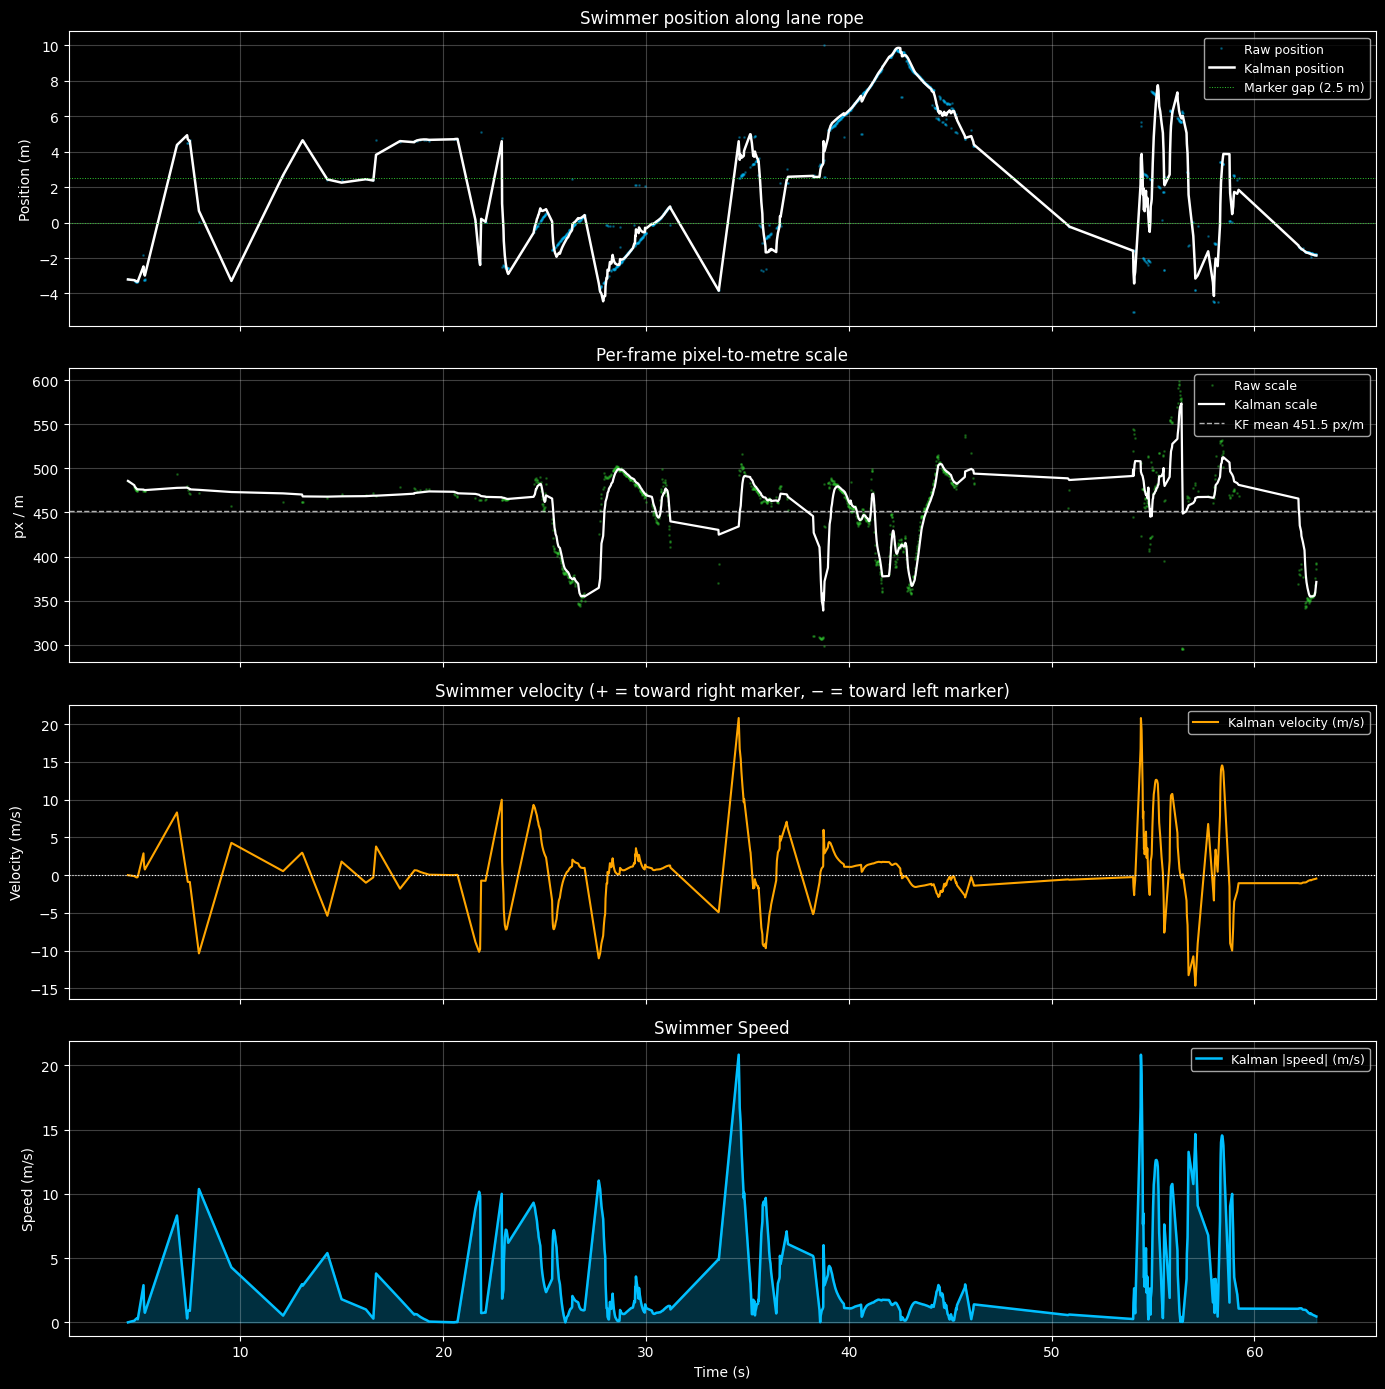

Kalman filter summary
  Position std raw / KF : 4.1345 / 4.1134 m
  Scale std raw / KF    : 51.4234 / 43.5899 px/m
  Peak |velocity|       : 20.8302 m/s  (74.989 km/h)
  Mean |velocity|       : 2.6976 m/s  (9.711 km/h)


In [5]:
import matplotlib.pyplot as plt

# Extract valid tracking records
valid = [r for r in tracking_records if r["pos_m"] is not None]


if not valid:
    print("No valid tracking records found to plot.")
else:
    # remove outliers from recorded data
    if len(valid) >= 5:
        pos_vals = np.array([v["pos_m"] for v in valid], dtype=float)
        scale_vals = np.array([v["px_per_m"] for v in valid], dtype=float)

        def _mad_inlier_mask(x, z_thresh=3.5):
            med = np.median(x)
            mad = np.median(np.abs(x - med))
            if mad < 1e-12:
                return np.ones_like(x, dtype=bool)
            robust_z = 0.6745 * (x - med) / mad
            return np.abs(robust_z) <= z_thresh

        pos_mask = _mad_inlier_mask(pos_vals, z_thresh=3.5)
        scale_mask = _mad_inlier_mask(scale_vals, z_thresh=3.5)

        # Optional temporal jump filter on position
        dpos = np.r_[0.0, np.abs(np.diff(pos_vals))]
        jump_thr = np.median(dpos) + 4.0 * np.std(dpos)
        jump_mask = dpos <= jump_thr if np.isfinite(jump_thr) and jump_thr > 0 else np.ones_like(dpos, dtype=bool)

        keep_mask = pos_mask & scale_mask & jump_mask
        removed = int((~keep_mask).sum())
        valid = [v for v, keep in zip(valid, keep_mask) if keep]

        print(f"Removed {removed} significant deviations; kept {len(valid)} records.")
    
    times      = np.array([v["time_s"] for v in valid], dtype=float)
    pos_raw    = np.array([v["pos_m"] for v in valid], dtype=float)
    scales_raw = np.array([v["px_per_m"] for v in valid], dtype=float)
    mode_seq   = [v["selection_mode"] for v in valid]

    # Use a simpler mapping for noise scale since we are only using "auto" here
    _MODE_NOISE_SCALE = {"auto": 1.0}

    def kalman_filter_pos_vel(times_s, pos_meas, mode_names, accel_var=3.0, meas_var=0.015):
        n = len(pos_meas)
        pos_est = np.zeros(n, dtype=float)
        vel_est = np.zeros(n, dtype=float)
        if n == 0:
            return pos_est, vel_est

        x = np.array([pos_meas[0], 0.0], dtype=float)
        P = np.diag([0.10**2, 1.00**2]).astype(float)
        pos_est[0], vel_est[0] = x

        for i in range(1, n):
            dt = max(times_s[i] - times_s[i - 1], 1.0 / FPS)
            F = np.array([[1.0, dt], [0.0, 1.0]], dtype=float)
            Q = accel_var * np.array([
                [dt**4 / 4.0, dt**3 / 2.0],
                [dt**3 / 2.0, dt**2],
            ], dtype=float)

            x = F @ x
            P = F @ P @ F.T + Q

            H = np.array([[1.0, 0.0]], dtype=float)
            R = np.array([[meas_var * _MODE_NOISE_SCALE.get(mode_names[i], 4.0)]], dtype=float)
            z = np.array([[pos_meas[i]]], dtype=float)

            y = z - H @ x.reshape(-1, 1)
            s_cov = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(s_cov)
            x = x + (K @ y).ravel()
            P = (np.eye(2) - K @ H) @ P

            pos_est[i], vel_est[i] = x

        return pos_est, vel_est

    def kalman_filter_scale(scale_meas, mode_names, process_var=0.20, meas_var=9.0):
        n = len(scale_meas)
        scale_est = np.zeros(n, dtype=float)
        if n == 0:
            return scale_est

        x = float(scale_meas[0])
        P = 25.0
        scale_est[0] = x

        for i in range(1, n):
            P = P + process_var
            R = meas_var * _MODE_NOISE_SCALE.get(mode_names[i], 4.0)
            K = P / (P + R)
            x = x + K * (scale_meas[i] - x)
            P = (1.0 - K) * P
            scale_est[i] = x

        return scale_est

    pos_kf, vel_kf = kalman_filter_pos_vel(times, pos_raw, mode_seq)
    scale_kf       = kalman_filter_scale(scales_raw, mode_seq)
    spd_kf         = np.abs(vel_kf)

    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

        # [0] Raw + filtered position
        axes[0].plot(times, pos_raw, ".", markersize=2, color="deepskyblue",
                     alpha=0.30, label="Raw position")
        axes[0].plot(times, pos_kf, "-", linewidth=1.8, color="white",
                     label="Kalman position")
        axes[0].axhline(0, color="limegreen", linewidth=0.7, linestyle=":")
        axes[0].axhline(MARKER_REAL_DIST_M, color="limegreen", linewidth=0.7, linestyle=":",
                        label=f"Marker gap ({MARKER_REAL_DIST_M} m)")
        axes[0].set_ylabel("Position (m)")
        axes[0].set_title("Swimmer position along lane rope")
        axes[0].legend(fontsize=9)
        axes[0].grid(alpha=0.25)

        # [1] Raw + filtered scale
        axes[1].plot(times, scales_raw, ".", markersize=2, color="limegreen", alpha=0.30,
                     label="Raw scale")
        axes[1].plot(times, scale_kf, "-", linewidth=1.6, color="white",
                     label="Kalman scale")
        axes[1].axhline(np.mean(scale_kf), color="white", linewidth=1.0, linestyle="--",
                        alpha=0.7, label=f"KF mean {np.mean(scale_kf):.1f} px/m")
        axes[1].set_ylabel("px / m")
        axes[1].set_title("Per-frame pixel-to-metre scale")
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.25)

        # [2] Signed velocity
        axes[2].plot(times, vel_kf, "-", linewidth=1.5, color="orange",
                     label="Kalman velocity (m/s)")
        axes[2].axhline(0, color="white", linewidth=0.8, linestyle=":")
        axes[2].set_ylabel("Velocity (m/s)")
        axes[2].set_title("Swimmer velocity (+ = toward right marker, − = toward left marker)")
        axes[2].legend(fontsize=9)
        axes[2].grid(alpha=0.25)

        # [3] Speed magnitude
        axes[3].fill_between(times, spd_kf, alpha=0.25, color="deepskyblue")
        axes[3].plot(times, spd_kf, "-", linewidth=1.8, color="deepskyblue",
                     label="Kalman |speed| (m/s)")
        axes[3].set_ylabel("Speed (m/s)")
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Swimmer Speed")
        axes[3].legend(fontsize=9)
        axes[3].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    print("Kalman filter summary")
    print(f"  Position std raw / KF : {np.std(pos_raw):.4f} / {np.std(pos_kf):.4f} m")
    print(f"  Scale std raw / KF    : {np.std(scales_raw):.4f} / {np.std(scale_kf):.4f} px/m")
    print(f"  Peak |velocity|       : {spd_kf.max():.4f} m/s  ({spd_kf.max() * 3.6:.3f} km/h)")
    print(f"  Mean |velocity|       : {spd_kf.mean():.4f} m/s  ({spd_kf.mean() * 3.6:.3f} km/h)")

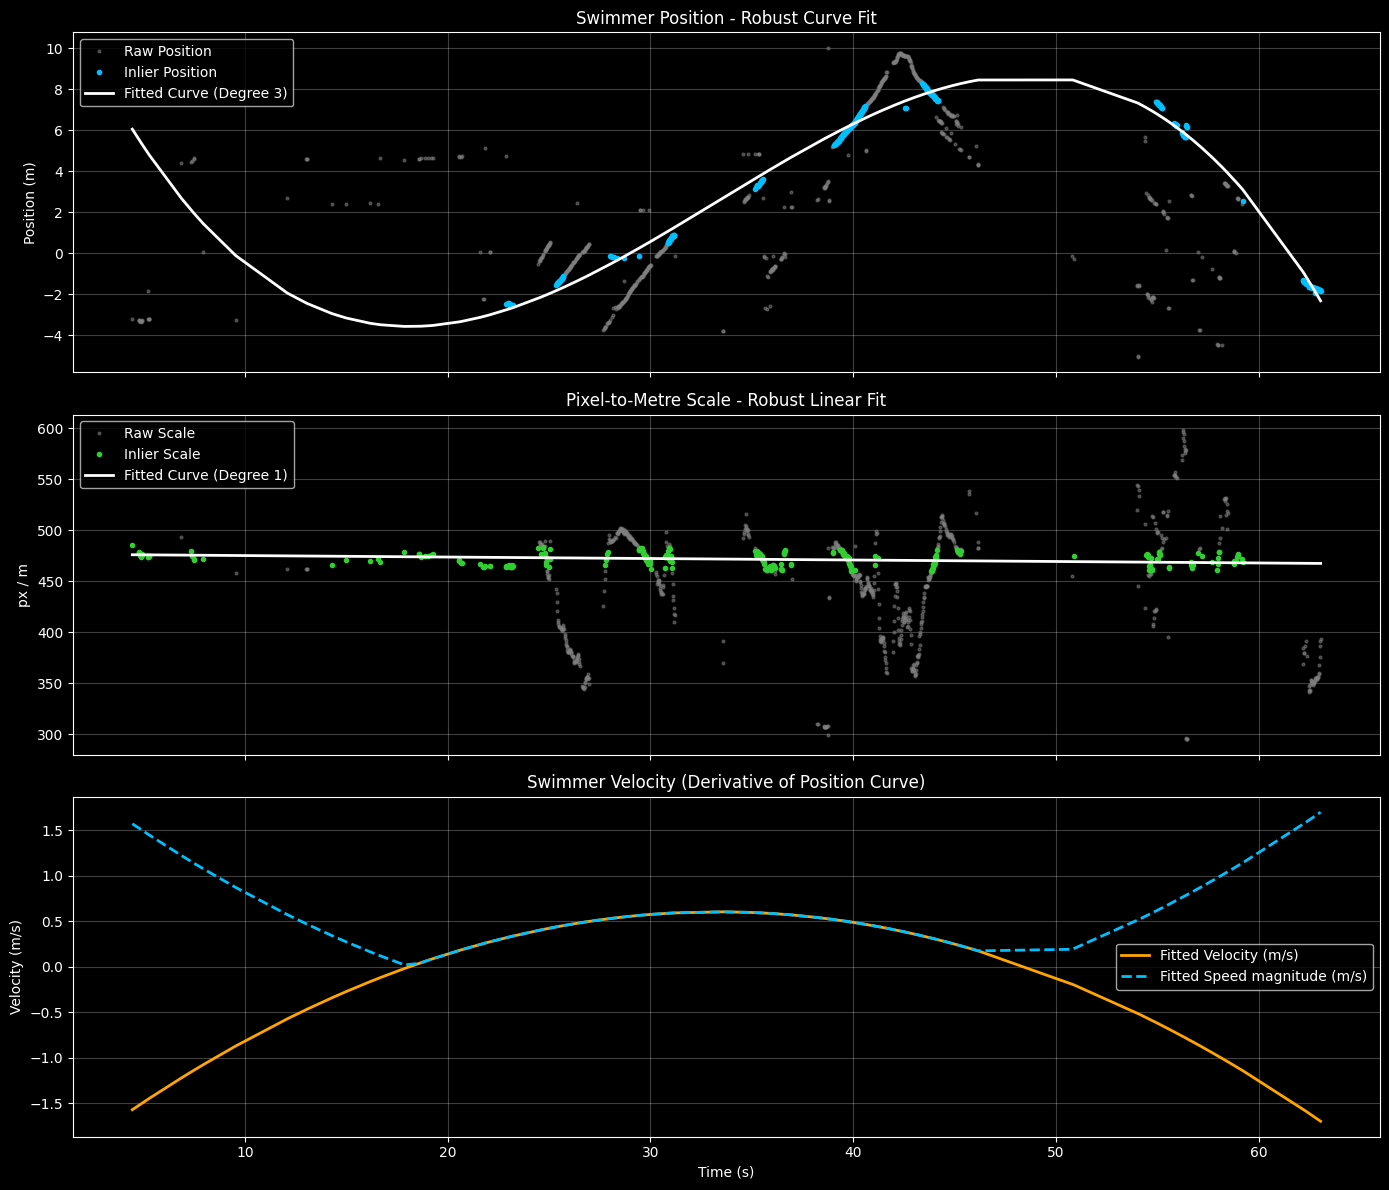

Curve Fit Summary:
  Fitted Position Equ. Coeffs (Deg 3) : [    -0.0009       0.087     -2.2948      14.623]
  Fitted Scale Equ. Coeffs (Deg 1)    : [    -0.1453      476.74]
  Peak |velocity| (from curve)        : 1.6996 m/s (6.119 km/h)
  Mean |velocity| (from curve)        : 0.5699 m/s (2.052 km/h)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define a function to perform a robust polynomial fit that iteratively drops outliers
def robust_poly_fit(x, y, deg=3, iterations=3, threshold=2.0):
    """
    Fits a polynomial of specified degree, iteratively ignoring points that are 
    more than `threshold` standard deviations away from the fit.
    """
    mask = np.ones(len(x), dtype=bool)
    for _ in range(iterations):
        if np.sum(mask) < deg + 1:
            break # Not enough points left
            
        p = np.polyfit(x[mask], y[mask], deg)
        y_fit = np.polyval(p, x)
        
        residuals = np.abs(y - y_fit)
        std_res = np.std(residuals[mask])
        
        if std_res < 1e-6:
            break
            
        # Keep points within `threshold` standard deviations of the residuals
        mask = residuals < (threshold * std_res)
        
    return p, y_fit, mask

if 'times' in locals() and len(times) > 0:
    # 1. Fit a cubic curve for position to capture normal swimming acceleration/deceleration gracefully
    pos_poly, pos_curve, pos_inliers = robust_poly_fit(times, pos_raw, deg=3, iterations=4, threshold=2.0)

    # 2. Fit a linear curve for the scale metric since perspective change over a lane is mostly linear / steady
    scale_poly, scale_curve, scale_inliers = robust_poly_fit(times, scales_raw, deg=1, iterations=4, threshold=2.0)

    # 3. Analytically calculate velocity (and thus speed) as the first derivative of the position curve
    pos_poly_deriv = np.polyder(pos_poly)
    vel_curve = np.polyval(pos_poly_deriv, times)
    spd_curve = np.abs(vel_curve)

    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

        # Position Plot
        axes[0].plot(times, pos_raw, ".", markersize=4, color="gray", alpha=0.5, label="Raw Position")
        axes[0].plot(times[pos_inliers], pos_raw[pos_inliers], ".", markersize=6, color="deepskyblue", label="Inlier Position")
        axes[0].plot(times, pos_curve, "-", linewidth=2, color="white", label="Fitted Curve (Degree 3)")
        axes[0].set_ylabel("Position (m)")
        axes[0].set_title("Swimmer Position - Robust Curve Fit")
        axes[0].legend(fontsize=10)
        axes[0].grid(alpha=0.25)

        # Scale Plot
        axes[1].plot(times, scales_raw, ".", markersize=4, color="gray", alpha=0.5, label="Raw Scale")
        axes[1].plot(times[scale_inliers], scales_raw[scale_inliers], ".", markersize=6, color="limegreen", label="Inlier Scale")
        axes[1].plot(times, scale_curve, "-", linewidth=2, color="white", label="Fitted Curve (Degree 1)")
        axes[1].set_ylabel("px / m")
        axes[1].set_title("Pixel-to-Metre Scale - Robust Linear Fit")
        axes[1].legend(fontsize=10)
        axes[1].grid(alpha=0.25)

        # Velocity Plot
        axes[2].plot(times, vel_curve, "-", linewidth=2, color="orange", label="Fitted Velocity (m/s)")
        axes[2].plot(times, spd_curve, "--", linewidth=2, color="deepskyblue", label="Fitted Speed magnitude (m/s)")
        axes[2].set_xlabel("Time (s)")
        axes[2].set_ylabel("Velocity (m/s)")
        axes[2].set_title("Swimmer Velocity (Derivative of Position Curve)")
        axes[2].legend(fontsize=10)
        axes[2].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    print("Curve Fit Summary:")
    print(f"  Fitted Position Equ. Coeffs (Deg 3) : {np.round(pos_poly, 4)}")
    print(f"  Fitted Scale Equ. Coeffs (Deg 1)    : {np.round(scale_poly, 4)}")
    print(f"  Peak |velocity| (from curve)        : {spd_curve.max():.4f} m/s ({spd_curve.max() * 3.6:.3f} km/h)")
    print(f"  Mean |velocity| (from curve)        : {spd_curve.mean():.4f} m/s ({spd_curve.mean() * 3.6:.3f} km/h)")
else:
    print("Warning: Insufficient data to fit curves.")

### **4. Advanced Processing: Linear Segment Stitching**
This implements the idea of identifying tracking "blocks," fitting them, 
and stitching them together by adjusting vertical offsets to remove marker-jump noise.

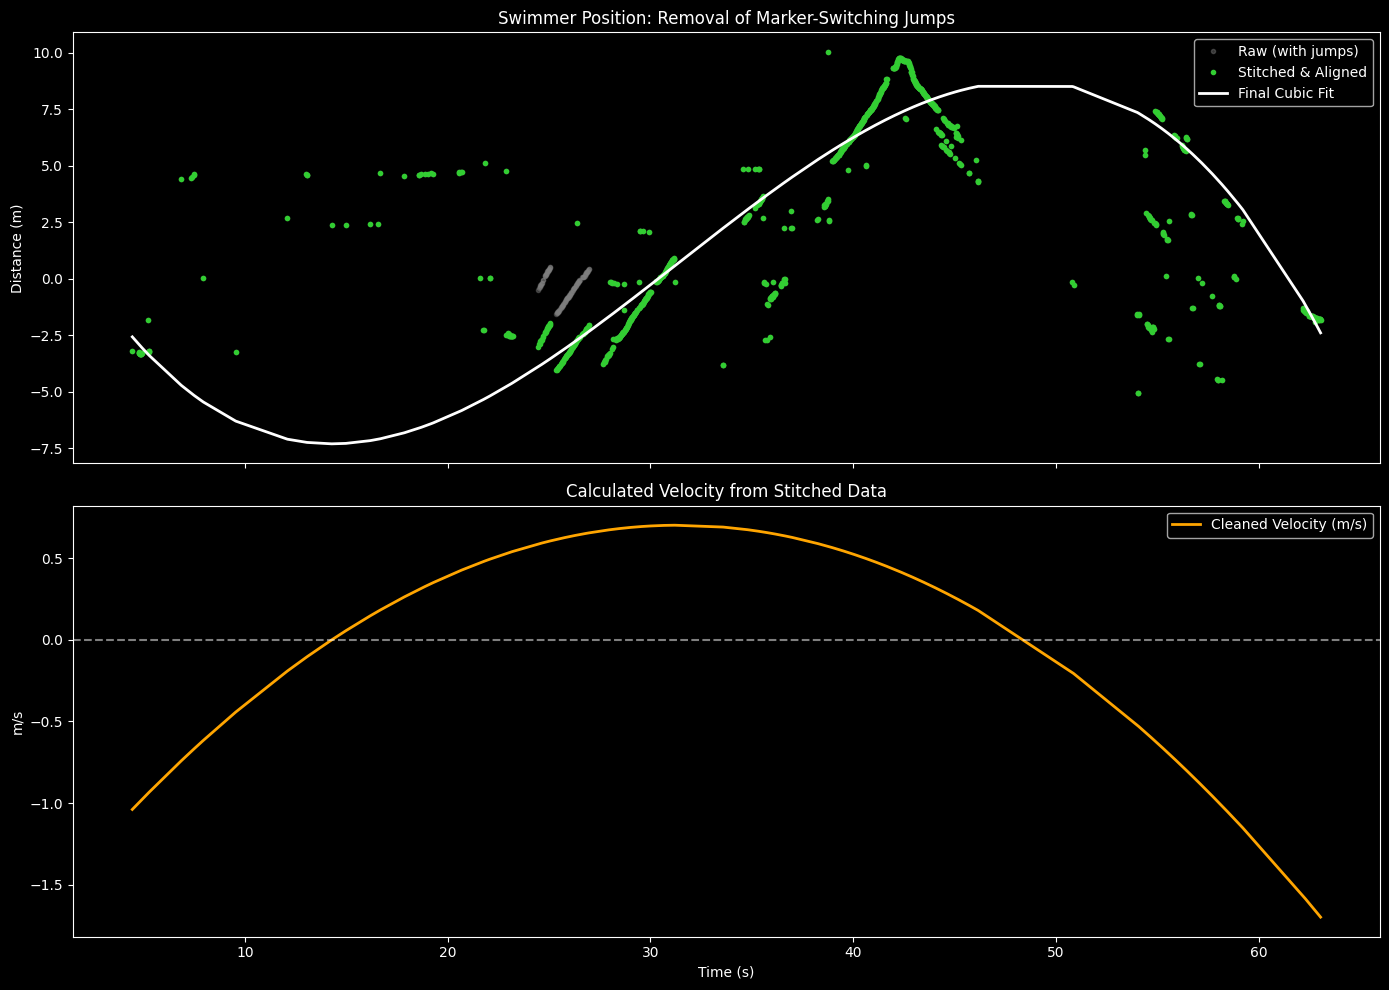

In [7]:
from sklearn.linear_model import RANSACRegressor


def stitch_tracking_segments(times, pos_raw, marker_dist=2.5, jump_threshold=1.2):
    """
    Identifies linear segments, fits them, and offsets them vertically to 
    create a continuous trajectory, handling marker-swapping 'jumps'.
    """
    if len(times) < 10:
        return pos_raw

    segments = []
    current_seg = [0]

    # 1. Segmentation based on sudden velocity jumps (likely marker swaps)
    for i in range(1, len(times)):
        dt = times[i] - times[i-1]
        if dt > 0.5:  # Handle large temporal gaps as new segments
            segments.append(current_seg)
            current_seg = [i]
            continue

        # Check for a physical jump that exceeds a realistic swimming burst
        dp = abs(pos_raw[i] - pos_raw[i-1])
        if dp > jump_threshold:
            segments.append(current_seg)
            current_seg = [i]
        else:
            current_seg.append(i)
    segments.append(current_seg)

    stitched_pos = np.copy(pos_raw)
    cumulative_offset = 0.0

    # 2. Fit and Stitch
    for i in range(len(segments)):
        idx = segments[i]
        if len(idx) < 5:
            continue  # Skip tiny noise fragments

        X = times[idx].reshape(-1, 1)
        y = pos_raw[idx]

        # Robust linear fit for this segment
        ransac = RANSACRegressor(residual_threshold=0.2)
        ransac.fit(X, y)

        if i > 0:
            # Predict where the PREVIOUS segment would be at the start of this segment
            prev_idx = segments[i-1]
            if len(prev_idx) >= 5:
                X_prev = times[prev_idx].reshape(-1, 1)
                y_prev = stitched_pos[prev_idx]

                # Fit previous segment to find its "exit" trajectory
                prev_fit = RANSACRegressor().fit(X_prev, y_prev)
                predicted_start = prev_fit.predict([[times[idx[0]]]])[0]

                # The jump should ideally be a multiple of the marker distance (2.5m)
                raw_start = ransac.predict([[times[idx[0]]]])[0]
                gap = predicted_start - raw_start

                # Snap the offset to the nearest marker distance increment
                snap_offset = round(gap / marker_dist) * marker_dist
                cumulative_offset += snap_offset

        stitched_pos[idx] += cumulative_offset

    return stitched_pos


# Execute the Stitching
if 'times' in locals() and len(times) > 0:
    # Perform the stitch
    pos_stitched = stitch_tracking_segments(
        times, pos_raw, marker_dist=MARKER_REAL_DIST_M)

    # Now perform your final smooth curve fit on the CLEANED data
    pos_poly, pos_curve, pos_inliers = robust_poly_fit(
        times, pos_stitched, deg=3)

    # Velocity is now much cleaner because the jumps are gone
    pos_poly_deriv = np.polyder(pos_poly)
    vel_curve = np.polyval(pos_poly_deriv, times)

    # Update Plotting to show the "Stitched" vs "Raw"
    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Top: Position Comparison
        axes[0].plot(times, pos_raw, ".", color="gray",
                     alpha=0.4, label="Raw (with jumps)")
        axes[0].plot(times, pos_stitched, "o", markersize=3,
                     color="limegreen", label="Stitched & Aligned")
        axes[0].plot(times, pos_curve, "-", color="white",
                     linewidth=2, label="Final Cubic Fit")
        axes[0].set_title(
            "Swimmer Position: Removal of Marker-Switching Jumps")
        axes[0].set_ylabel("Distance (m)")
        axes[0].legend()

        # Bottom: Clean Velocity
        axes[1].plot(times, vel_curve, "-", color="orange",
                     linewidth=2, label="Cleaned Velocity (m/s)")
        axes[1].axhline(0, color="white", linestyle="--", alpha=0.5)
        axes[1].set_title("Calculated Velocity from Stitched Data")
        axes[1].set_xlabel("Time (s)")
        axes[1].set_ylabel("m/s")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

### **5. Refined Modeling: Spline Fitting for Turn Dynamics**
Replacing the rigid cubic fit with a flexible Spline to capture the 
sharp inflection point at the turn and the linear speed of the laps.

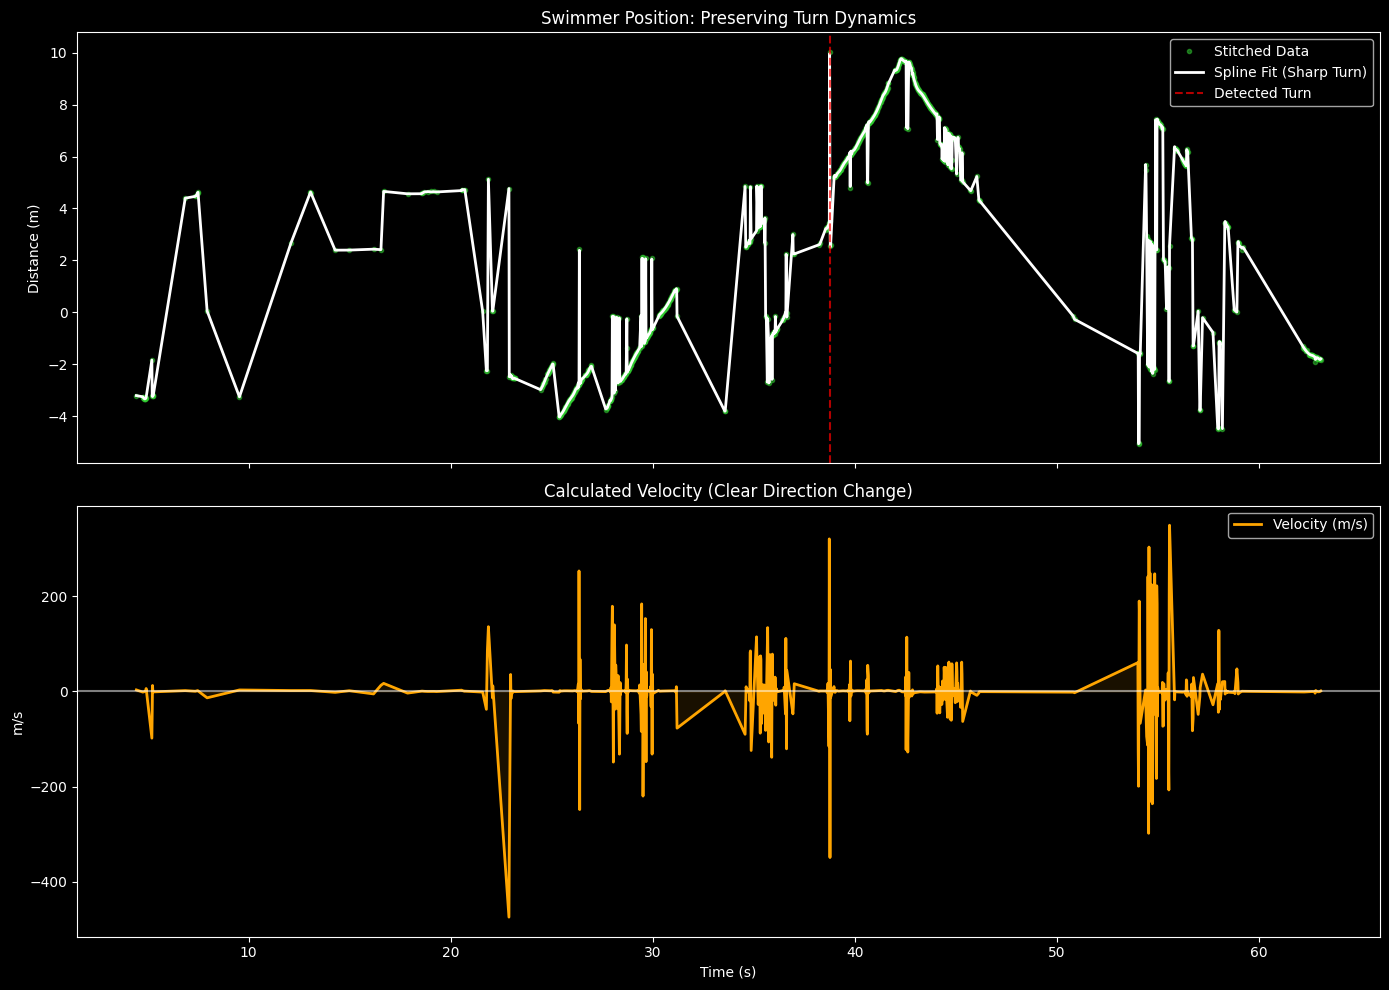

Turn detected at: 38.75 seconds
Max Speed: 474.80 m/s


In [8]:
from scipy.interpolate import UnivariateSpline

if 'times' in locals() and len(times) > 10:
    # 1. Use a Univariate Spline instead of a simple polynomial
    # 's' is the smoothing factor. Lower 's' = follows data more closely (sharper turns).
    # 'k' is the degree. k=3 allows for acceleration changes, but splines are piecewise.
    spline = UnivariateSpline(times, pos_stitched, k=3, s=0.5)
    pos_curve = spline(times)

    # 2. Derive velocity directly from the spline
    vel_spline = spline.derivative()
    vel_curve = vel_spline(times)
    spd_curve = np.abs(vel_curve)

    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Position Plot - Should now look more like a clear "/\"
        axes[0].plot(times, pos_stitched, "o", markersize=3,
                     color="limegreen", alpha=0.5, label="Stitched Data")
        axes[0].plot(times, pos_curve, "-", color="white",
                     linewidth=2, label="Spline Fit (Sharp Turn)")

        # Identify and mark the turn (inflection point)
        turn_idx = np.argmax(
            pos_curve) if vel_curve[0] > 0 else np.argmin(pos_curve)
        axes[0].axvline(times[turn_idx], color="red",
                        linestyle="--", alpha=0.7, label="Detected Turn")

        axes[0].set_title("Swimmer Position: Preserving Turn Dynamics")
        axes[0].set_ylabel("Distance (m)")
        axes[0].legend()

        # Velocity Plot - Should show a sharper transition through zero
        axes[1].plot(times, vel_curve, "-", color="orange",
                     linewidth=2, label="Velocity (m/s)")
        axes[1].fill_between(times, 0, vel_curve, color="orange", alpha=0.1)
        axes[1].axhline(0, color="white", linestyle="-", alpha=0.5)
        axes[1].set_title("Calculated Velocity (Clear Direction Change)")
        axes[1].set_xlabel("Time (s)")
        axes[1].set_ylabel("m/s")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    print(f"Turn detected at: {times[turn_idx]:.2f} seconds")
    print(f"Max Speed: {spd_curve.max():.2f} m/s")

Keeping 784 samples, dropped 154 outliers with |velocity| > 5.0 m/s.


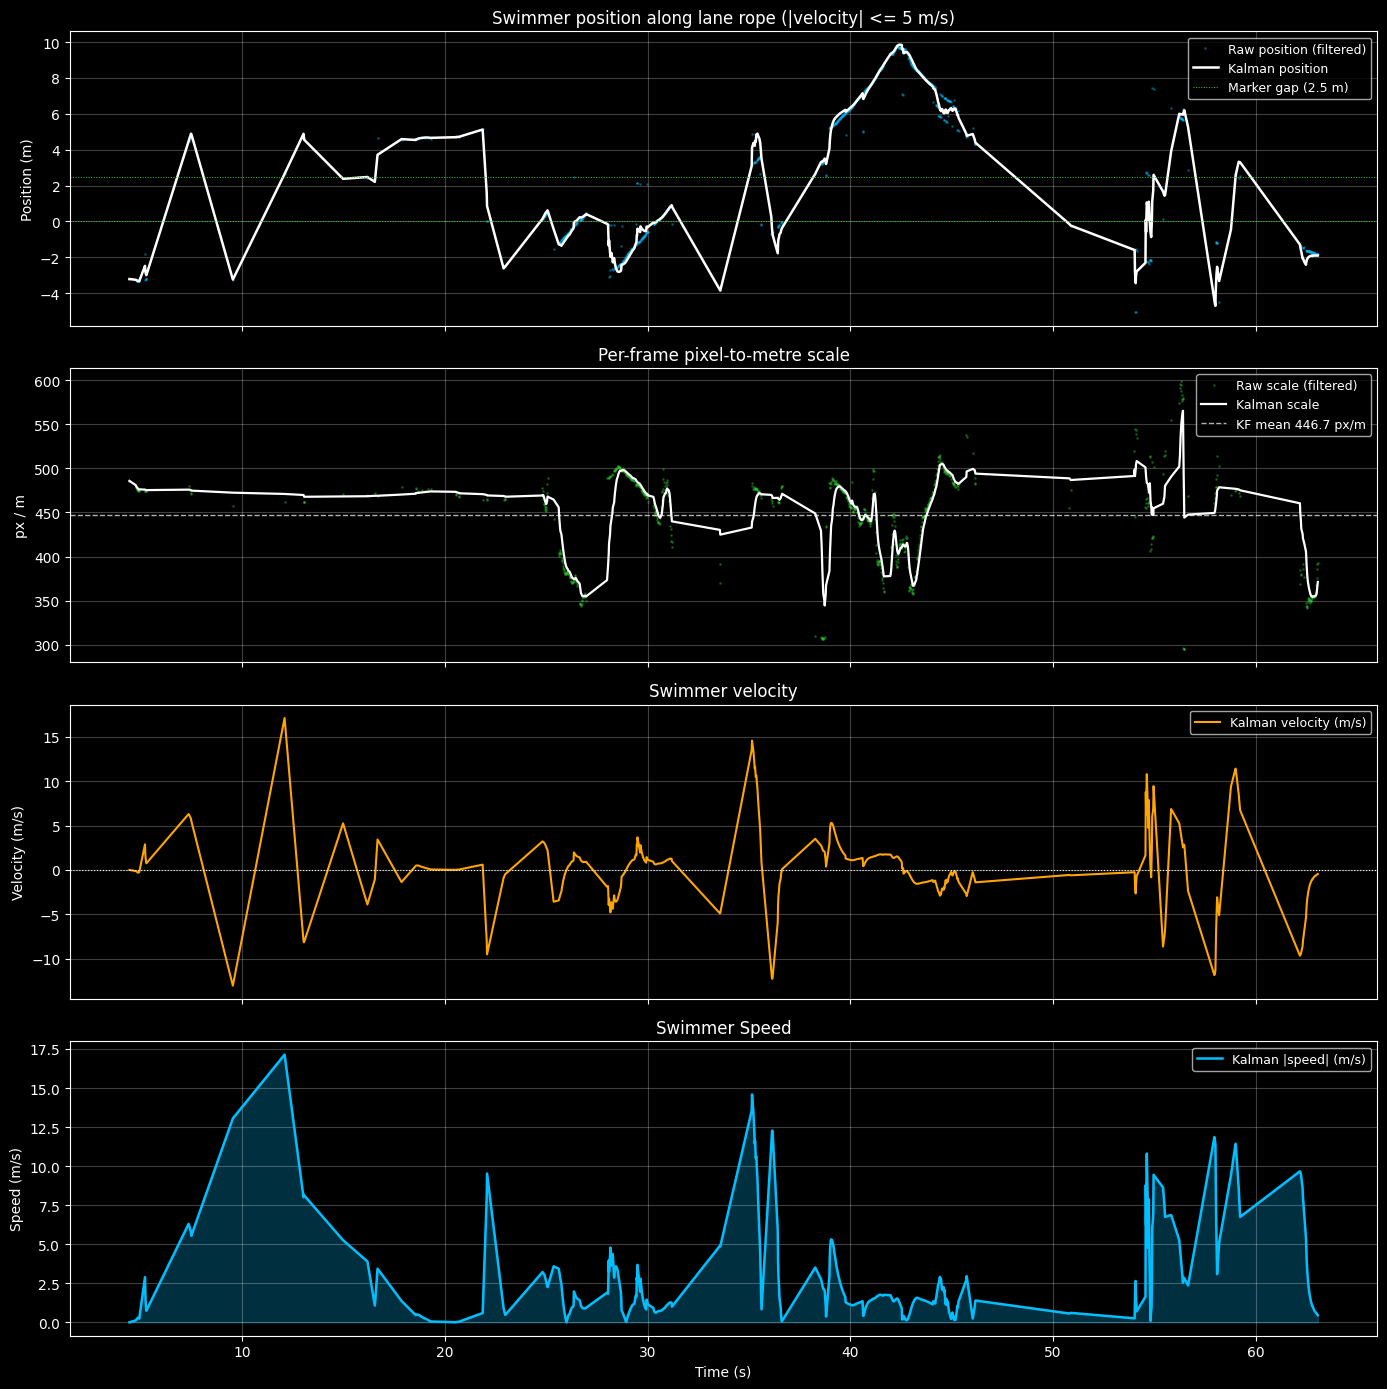

Filtered summary
  Peak |velocity| : 17.1367 m/s  (61.692 km/h)
  Mean |velocity| : 2.2535 m/s  (8.113 km/h)


In [9]:
# Filter out outliers based on velocity threshold
VEL_MAX = 5.0

if "times" not in locals() or "pos_raw" not in locals() or "scales_raw" not in locals() or "vel_kf" not in locals():
    print("Missing required variables (times, pos_raw, scales_raw, vel_kf).")
else:
    base_mask = np.isfinite(vel_kf) & (np.abs(vel_kf) <= VEL_MAX)
    kept = int(base_mask.sum())
    dropped = int((~base_mask).sum())
    print(f"Keeping {kept} samples, dropped {dropped} outliers with |velocity| > {VEL_MAX} m/s.")

    times_f = times[base_mask]
    pos_raw_f = pos_raw[base_mask]
    scales_raw_f = scales_raw[base_mask]

    if "mode_seq" in locals() and len(mode_seq) == len(base_mask):
        mode_seq_f = [m for m, k in zip(mode_seq, base_mask) if k]
    else:
        mode_seq_f = ["auto"] * len(times_f)

    # Recompute filtered Kalman tracks to keep plots consistent
    pos_kf_f, vel_kf_f = kalman_filter_pos_vel(times_f, pos_raw_f, mode_seq_f)
    scale_kf_f = kalman_filter_scale(scales_raw_f, mode_seq_f)
    spd_kf_f = np.abs(vel_kf_f)

    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

        # [0] Position
        axes[0].plot(times_f, pos_raw_f, ".", markersize=2, color="deepskyblue", alpha=0.30, label="Raw position (filtered)")
        axes[0].plot(times_f, pos_kf_f, "-", linewidth=1.8, color="white", label="Kalman position")
        axes[0].axhline(0, color="limegreen", linewidth=0.7, linestyle=":")
        axes[0].axhline(MARKER_REAL_DIST_M, color="limegreen", linewidth=0.7, linestyle=":",
                        label=f"Marker gap ({MARKER_REAL_DIST_M} m)")
        axes[0].set_ylabel("Position (m)")
        axes[0].set_title("Swimmer position along lane rope (|velocity| <= 5 m/s)")
        axes[0].legend(fontsize=9)
        axes[0].grid(alpha=0.25)

        # [1] Scale
        axes[1].plot(times_f, scales_raw_f, ".", markersize=2, color="limegreen", alpha=0.30, label="Raw scale (filtered)")
        axes[1].plot(times_f, scale_kf_f, "-", linewidth=1.6, color="white", label="Kalman scale")
        axes[1].axhline(np.mean(scale_kf_f), color="white", linewidth=1.0, linestyle="--", alpha=0.7,
                        label=f"KF mean {np.mean(scale_kf_f):.1f} px/m")
        axes[1].set_ylabel("px / m")
        axes[1].set_title("Per-frame pixel-to-metre scale")
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.25)

        # [2] Velocity
        axes[2].plot(times_f, vel_kf_f, "-", linewidth=1.5, color="orange", label="Kalman velocity (m/s)")
        axes[2].axhline(0, color="white", linewidth=0.8, linestyle=":")
        axes[2].set_ylabel("Velocity (m/s)")
        axes[2].set_title("Swimmer velocity")
        axes[2].legend(fontsize=9)
        axes[2].grid(alpha=0.25)

        # [3] Speed
        axes[3].fill_between(times_f, spd_kf_f, alpha=0.25, color="deepskyblue")
        axes[3].plot(times_f, spd_kf_f, "-", linewidth=1.8, color="deepskyblue", label="Kalman |speed| (m/s)")
        axes[3].set_ylabel("Speed (m/s)")
        axes[3].set_xlabel("Time (s)")
        axes[3].set_title("Swimmer Speed")
        axes[3].legend(fontsize=9)
        axes[3].grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    print("Filtered summary")
    print(f"  Peak |velocity| : {spd_kf_f.max():.4f} m/s  ({spd_kf_f.max() * 3.6:.3f} km/h)")
    print(f"  Mean |velocity| : {spd_kf_f.mean():.4f} m/s  ({spd_kf_f.mean() * 3.6:.3f} km/h)")